# Grafics and data things


In [446]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df = pd.read_csv("../data/processed/full_dataset.csv")
df.head()

,title,text,subject,date,target,full_text,text_length,word_count,title_length,year,month,weekday
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,0,republican faction congress who voted month hu...,1363,187,64,2017.0,12.0,6.0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,0,allowed first time enlist military starting mo...,1431,189,64,2017.0,12.0,4.0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,0,link between russia president election campaig...,1342,185,60,2017.0,12.0,6.0
3,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,0,postal service friday charge much more ship pa...,1304,193,69,2017.0,12.0,4.0
4,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,2017-12-29,0,white house friday wa set kick off talk next w...,1416,197,64,2017.0,12.0,4.0


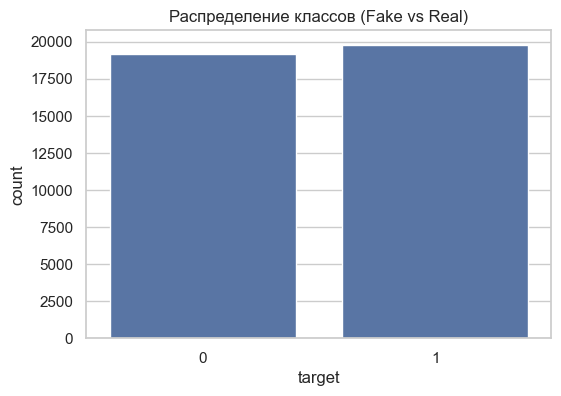

In [447]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Распределение классов (Fake vs Real)")
plt.show()

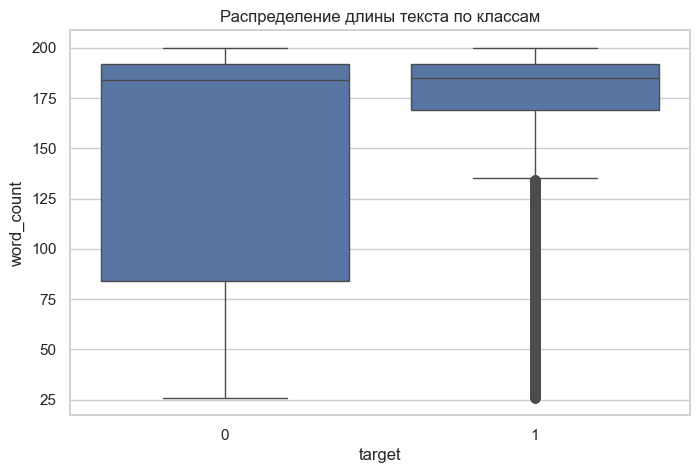

In [448]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="word_count", data=df)
plt.title("Распределение длины текста по классам")
plt.show()

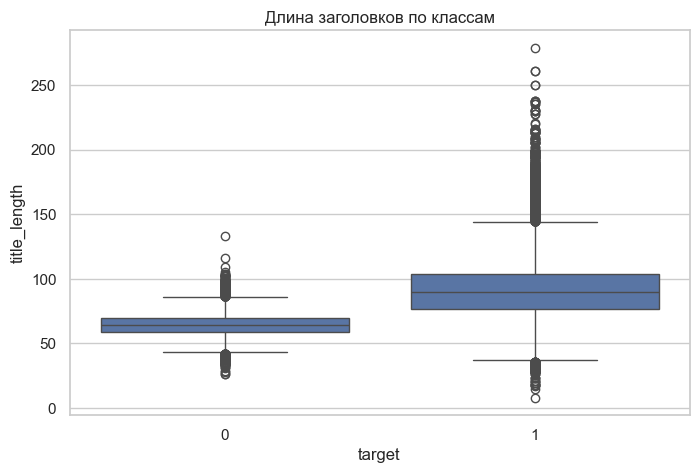

In [449]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="title_length", data=df)
plt.title("Длина заголовков по классам")
plt.show()

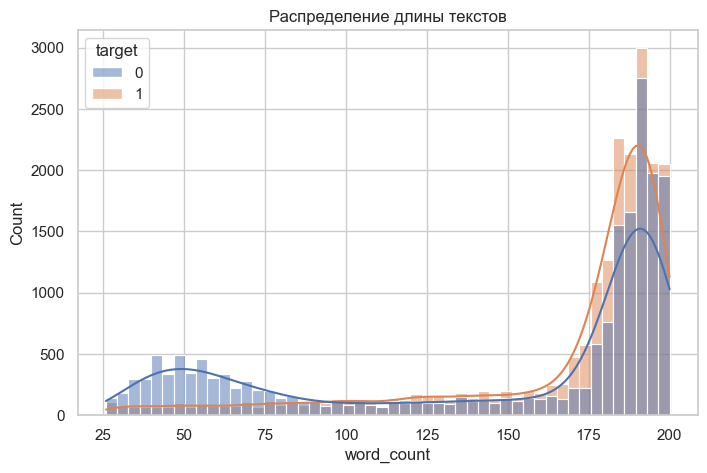

In [450]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="word_count", hue="target", bins=50, kde=True)
plt.title("Распределение длины текстов")
plt.show()

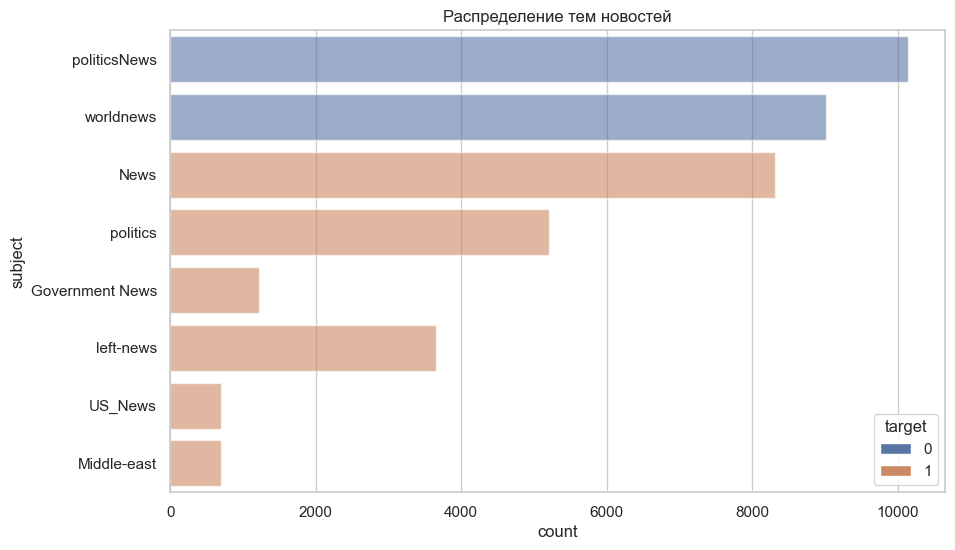

In [451]:
# темы новостей я не буду учитывать
plt.figure(figsize=(10,6))
ax = sns.countplot(y="subject", hue="target", data=df)

for patch in ax.patches:
    patch.set_alpha(0.6)

plt.title("Распределение тем новостей")
plt.show()

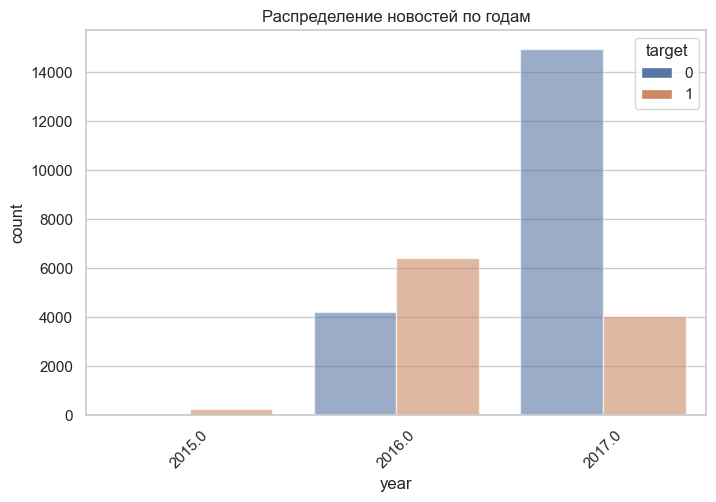

In [452]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="year", hue="target", data=df)

for patch in ax.patches:
    patch.set_alpha(0.6)

plt.title("Распределение новостей по годам")
plt.xticks(rotation=45)
plt.show()

          word  count
0         with  61341
1           wa  60736
2           ha  45074
3          not  40668
4         from  40626
5         have  39849
6          who  36425
7    president  32777
8        state  31849
9          but  30091
10       would  27334
11       about  26820
12        will  25389
13         had  23631
14       their  22284
15        been  21959
16      people  21449
17       after  21279
18        year  21157
19  republican  20418
20         one  20131
21         she  19702
22        were  19505
23       which  19444
24         her  19421
25         out  18843
26        more  18281
27        what  17896
28         all  17387
29      donald  17339
30        when  17218
31         new  15767
32       house  15565
33          it  15400
34       there  15358
35       obama  15068
36        over  15030
37  government  14647
38        time  14572
39         our  14542

Всего уникальных слов: 68579


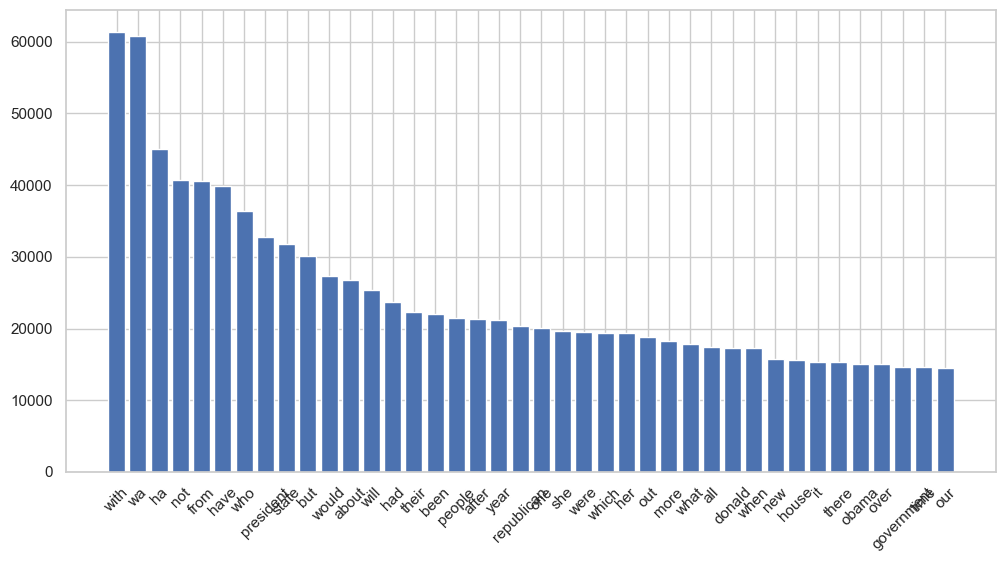

In [453]:
# частота слов

from collections import Counter
import matplotlib.pyplot as plt


all_text = " ".join(df["full_text"].astype(str))

top_n = 40 # сколько слов выводить

words = all_text.split()

word_counts = Counter(words)

sorted_words = word_counts.most_common()

freq_df = pd.DataFrame(sorted_words, columns=["word", "count"])

print(freq_df.head(top_n ))
print("\nВсего уникальных слов:", len(freq_df))

plt.figure(figsize=(12, 6))
plt.bar(freq_df["word"][:top_n], freq_df["count"][:top_n])
plt.xticks(rotation=45)
plt.show()

In [454]:
from collections import Counter
import pandas as pd

# тексты по классам
real_text = " ".join(df[df["target"] == 0]["full_text"].astype(str))
fake_text = " ".join(df[df["target"] == 1]["full_text"].astype(str))

# слова
real_words = real_text.split()
fake_words = fake_text.split()

# частоты
real_counts = Counter(real_words)
fake_counts = Counter(fake_words)

# все уникальные слова
all_words = set(real_counts.keys()) | set(fake_counts.keys())

rows = []

for word in all_words:
    real_count = real_counts.get(word, 0)
    fake_count = fake_counts.get(word, 0)

    diff = fake_count - real_count # + => чаще в fake
    abs_diff = abs(diff)

    rows.append({
        "word": word,
        "real_count": real_count,
        "fake_count": fake_count,
        "diff": diff,
        "abs_diff": abs_diff
    })

diff_df = pd.DataFrame(rows)

diff_df = diff_df.sort_values("abs_diff", ascending=False)

print("ТОП слов с максимальной разницей между классами:")
print(diff_df.head(100))


big_diff = diff_df[diff_df["abs_diff"] > 6000]

with open("../data/processed/high_difference_words.txt", "w", encoding="utf-8") as f:
    for _, row in big_diff.iterrows():
        f.write(
            f"{row['word']} | "
            f"real={row['real_count']} | "
            f"fake={row['fake_count']} | "
            f"diff={row['diff']}\n"
        )

print("\nФайл high_difference_words.txt сохранён")
print("Количество слов:", len(big_diff))

ТОП слов с максимальной разницей между классами:
            word  real_count  fake_count   diff  abs_diff
3043          wa       25240       35496  10256     10256
44045      about        8521       18299   9778      9778
65473        she        5022       14680   9658      9658
49930       what        4135       13761   9626      9626
63932        her        4955       14466   9511      9511
...          ...         ...         ...    ...       ...
943        month        5031        2523  -2508      2508
68528       more        7887       10394   2507      2507
39769        tax        4540        2066  -2474      2474
22409       well        2034        4499   2465      2465
24852  spokesman        2880         417  -2463      2463

[100 rows x 5 columns]

Файл high_difference_words.txt сохранён
Количество слов: 20


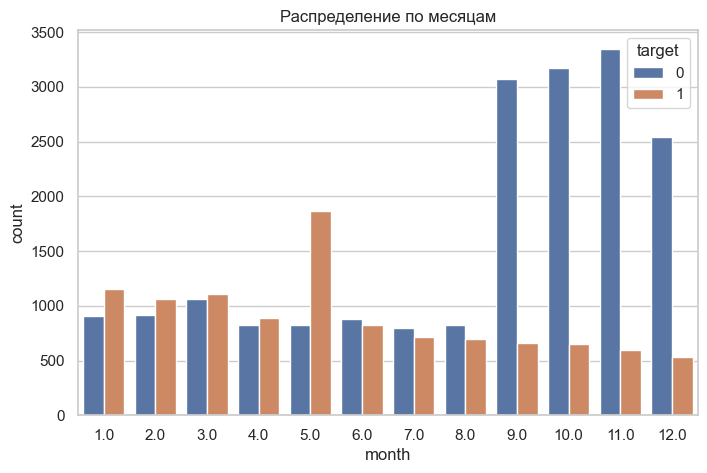

In [455]:
plt.figure(figsize=(8,5))
sns.countplot(x="month", hue="target", data=df)
plt.title("Распределение по месяцам")
plt.show()

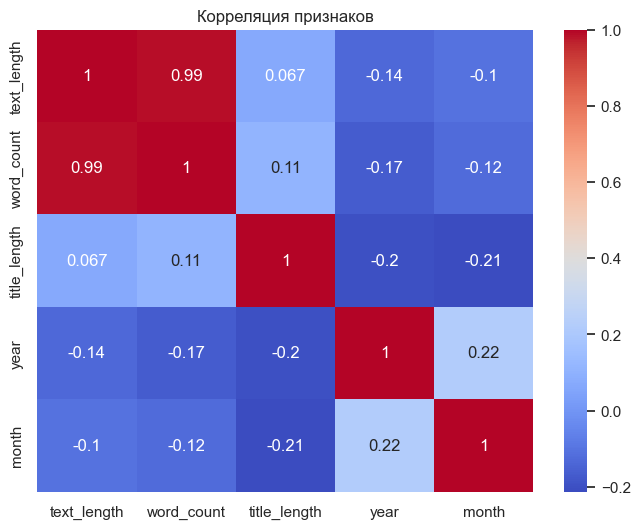

In [456]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["text_length", "word_count", "title_length", "year", "month"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

In [457]:
df.groupby("target")["word_count"].mean()

target
0    147.073102
1    169.126011
Name: word_count, dtype: float64

In [458]:
print(df.groupby("target")[["word_count", "title_length"]].describe())

       word_count                                                           \
            count        mean        std   min    25%    50%    75%    max   
target                                                                       
0         19165.0  147.073102  59.362890  26.0   84.0  184.0  192.0  200.0   
1         19792.0  169.126011  39.443472  26.0  169.0  185.0  192.0  200.0   

       title_length                                                        
              count       mean        std   min   25%   50%    75%    max  
target                                                                     
0           19165.0  64.678529   9.135704  26.0  59.0  64.0   70.0  133.0  
1           19792.0  93.953971  27.010231   8.0  77.0  90.0  104.0  279.0  


## выводы
признаки даты и тематики частично коррелируют: subject нет смысла брать, даты распределены с явным перевесом (формат дат разный в статьях и отследить все очень тяжело). Чтобы избежать переобучения, я эти признаки исключу из основной модели.

по количеству слов выявил, что модель запоминает преимущественно эти самые слова в статьях (именно поэтому выводил разницу самых частовстречаемых слов и удалял их в preprocessed из текста). я пытался играться с длиной подаваемого текста (балансировал боксплоты), убирал слова и дальше, но это не помогает. датасет имеет слишком четкое разделение на классы. на данном этапе я считаю, что для выбранного датасета я достиг наилучших реальных результатов.